# ***EDA***

In [87]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go
import plotly.offline as py
from plotly.offline import iplot
import plotly.express as px
from plotly.subplots import make_subplots

In [2]:
train = pd.read_csv(r'C:\Users\georg\OneDrive\Рабочий стол\kaggle\Home-Credit-Default-Risk\data\application_train.csv')
test = pd.read_csv(r'C:\Users\georg\OneDrive\Рабочий стол\kaggle\Home-Credit-Default-Risk\data\application_test.csv')
#bureau = pd.read_csv(r'C:\Users\georg\OneDrive\Рабочий стол\kaggle\Home-Credit-Default-Risk\data\bureau.csv')
#bureau_balance = pd.read_csv(r'C:\Users\georg\OneDrive\Рабочий стол\kaggle\Home-Credit-Default-Risk\data\bureau_balance.csv')
#pos_cash_balance = pd.read_csv(r'C:\Users\georg\OneDrive\Рабочий стол\kaggle\Home-Credit-Default-Risk\data\POS_CASH_balance.csv')
#previous_application = pd.read_csv(r'C:\Users\georg\OneDrive\Рабочий стол\kaggle\Home-Credit-Default-Risk\data\previous_application.csv')
#credit_card_balance = pd.read_csv(r'C:\Users\georg\OneDrive\Рабочий стол\kaggle\Home-Credit-Default-Risk\data\credit_card_balance.csv')
#installments_payments = pd.read_csv(r'C:\Users\georg\OneDrive\Рабочий стол\kaggle\Home-Credit-Default-Risk\data\installments_payments.csv')

### ***Таргет***

***Check for missing data***

In [9]:
total = train.isnull().sum().sort_values(ascending = False)
percent = (train.isnull().sum() / len(train) * 100).sort_values(ascending = False).round(1)
missing_train = pd.concat([total, percent], axis = 1, keys = ['total', 'percent'])

In [10]:
missing_train

,total,percent
COMMONAREA_MEDI,214865,69.9
COMMONAREA_AVG,214865,69.9
COMMONAREA_MODE,214865,69.9
NONLIVINGAPARTMENTS_MODE,213514,69.4
NONLIVINGAPARTMENTS_AVG,213514,69.4
...,...,...
NAME_HOUSING_TYPE,0,0.0
NAME_FAMILY_STATUS,0,0.0
NAME_EDUCATION_TYPE,0,0.0
NAME_INCOME_TYPE,0,0.0


***Distribution of AMT_CREDIT***

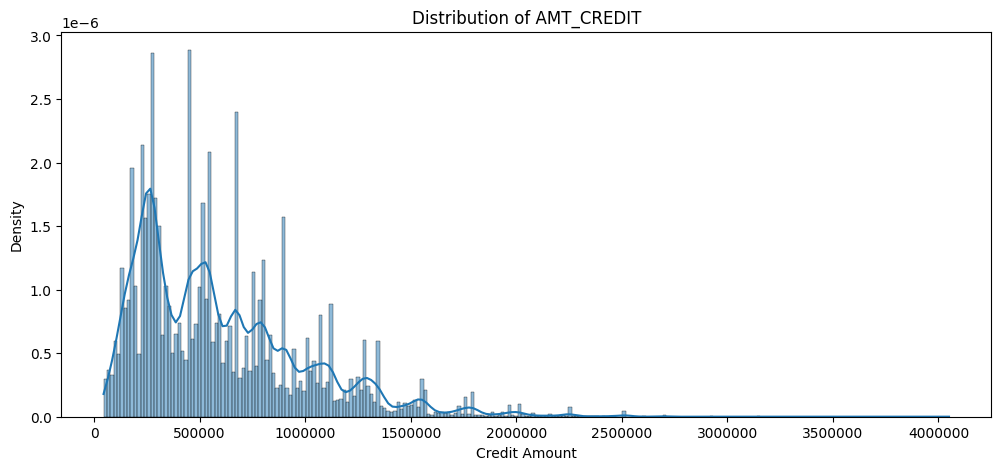

In [11]:
plt.figure(figsize=(12, 5))
sns.histplot(data=train, x='AMT_CREDIT', kde=True, stat='density')
plt.title('Distribution of AMT_CREDIT')
plt.xlabel('Credit Amount')
plt.ylabel('Density')
plt.ticklabel_format(style='plain', axis='x') 
plt.show()

***Distribution of AMT_ICOME_TOTAL***

***Распределение зп***

In [15]:
train['AMT_INCOME_TOTAL'].describe()

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

In [18]:
train['AMT_INCOME_TOTAL'].quantile([0.90,  0.95, 0.99, 1.0])

0.90       270000.0
0.95       337500.0
0.99       472500.0
1.00    117000000.0
Name: AMT_INCOME_TOTAL, dtype: float64

In [ ]:
log_income = np.log1p(train['AMT_INCOME_TOTAL'])
Q1 = log_income.quantile(0.25)
Q3 = log_income.quantile(0.75)
IQR_log = Q3 - Q1
upper_bound_log = Q3 + 1.5 * IQR_log
upper_bound_real = np.expm1(upper_bound_log)
print(f"Граница выброса (Log-IQR): {upper_bound_real:,.0f}")
print(f"Выбросов: {(train['AMT_INCOME_TOTAL'] > upper_bound_real).sum()}")

Граница выброса (Log-IQR): 489,027
Выбросов: 2981


In [ ]:
is_outlier = train['AMT_INCOME_TOTAL'] > upper_bound_real
outlier_default_rate = train.loc[is_outlier, 'TARGET'].mean()
normal_default_rate = train.loc[~is_outlier, 'TARGET'].mean()
print(f"Выбросов: {is_outlier.sum()}")
print(f"Default Rate (Outliers):  {outlier_default_rate:.4f} ({outlier_default_rate*100:.2f}%)")
print(f"Default Rate (Normal):    {normal_default_rate:.4f} ({normal_default_rate*100:.2f}%)")
print(f"Разница (Lift):           {(outlier_default_rate / normal_default_rate - 1)*100:+.2f}%")

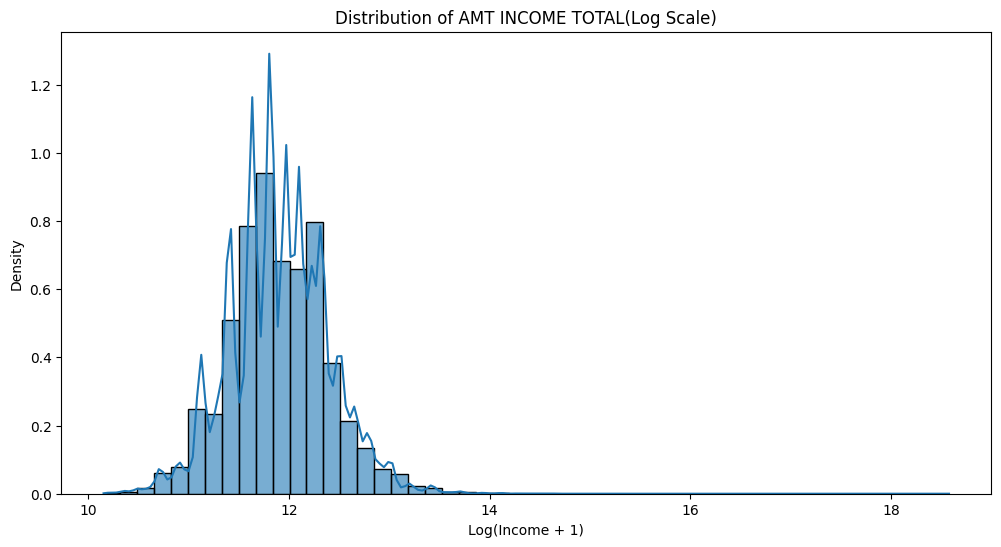

In [28]:
plt.figure(figsize = (12, 6))
sns.histplot(data = train, x = np.log1p(train['AMT_INCOME_TOTAL']), kde = True, stat = 'density', bins = 50, alpha = 0.6)
plt.title("Distribution of AMT INCOME TOTAL(Log Scale)")
plt.xlabel('Log(Income + 1)')
plt.ylabel('Density')
plt.show()

***Вывод:***
- У нас есть выбросы(outliners), но они возращают 5 из 100 клиентов и на 33% выше отдают кредит
- Оснонвая у нас масса 145-162к$
- От 22к до 117k
- Всех outliners оставляем, проблем для бустинга не доставят

***Distribution of AMT_GOOD_PRICE***

In [29]:
train['AMT_GOODS_PRICE'].describe()

count    3.072330e+05
mean     5.383962e+05
std      3.694465e+05
min      4.050000e+04
25%      2.385000e+05
50%      4.500000e+05
75%      6.795000e+05
max      4.050000e+06
Name: AMT_GOODS_PRICE, dtype: float64

In [35]:
train['AMT_GOODS_PRICE'].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999])

0.250     238500.0
0.500     450000.0
0.750     679500.0
0.900    1093500.0
0.950    1305000.0
0.990    1800000.0
0.999    2250000.0
Name: AMT_GOODS_PRICE, dtype: float64

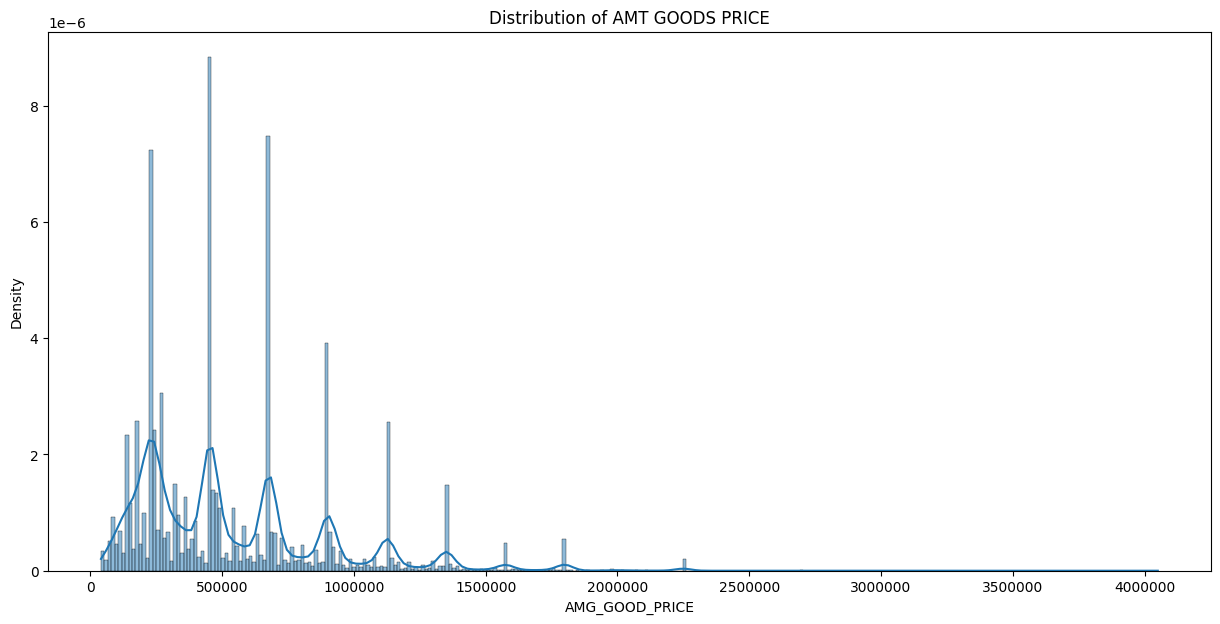

In [37]:
plt.figure(figsize = (15, 7))
sns.histplot(data = train, x = train['AMT_GOODS_PRICE'], kde = True, stat = 'density')
plt.title('Distribution of AMT GOODS PRICE')
plt.xlabel('AMG_GOOD_PRICE')
plt.ylabel('Density')
plt.ticklabel_format(style='plain', axis='x') 
plt.show()

In [58]:
bins = np.arange(0, 4_500_000, 250_000)
binned = pd.cut(train['AMT_GOODS_PRICE'], bins = bins, include_lowest=True)
bin_counts = binned.value_counts().sort_index()

AMT_GOODS_PRICE
(-0.001, 250000.0]        84891
(250000.0, 500000.0]      97727
(500000.0, 750000.0]      57883
(750000.0, 1000000.0]     32613
(1000000.0, 1250000.0]    17549
(1250000.0, 1500000.0]     9656
(1500000.0, 1750000.0]     3066
(1750000.0, 2000000.0]     2755
(2000000.0, 2250000.0]      984
(2250000.0, 2500000.0]       54
(2500000.0, 2750000.0]       20
(2750000.0, 3000000.0]        5
(3000000.0, 3250000.0]       12
(3250000.0, 3500000.0]        4
(3500000.0, 3750000.0]        5
(3750000.0, 4000000.0]        1
(4000000.0, 4250000.0]        8
Name: count, dtype: int64

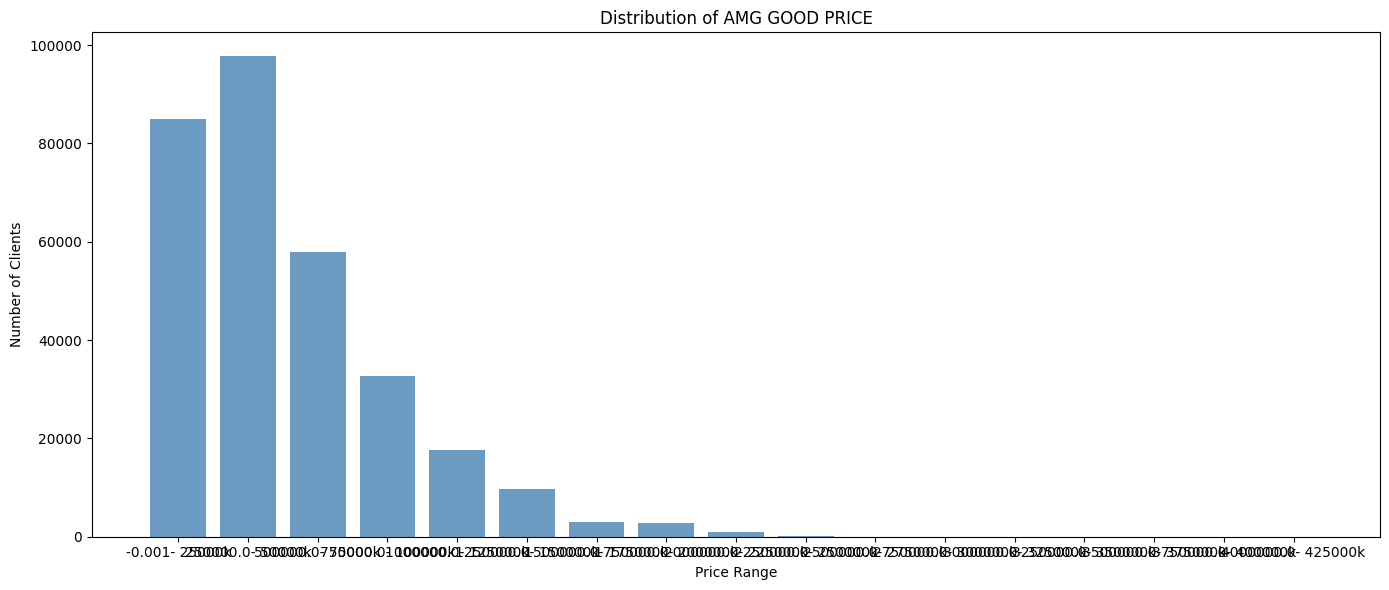

In [60]:
clean_labels = (bin_counts.index.astype(str).str.strip('()[]').str.replace(',', '-', regex = False).str[:-3] + 'k')

plt.figure(figsize = (14, 6))
plt.bar(clean_labels, bin_counts.values, color = 'steelblue', alpha = 0.8)
plt.title('Distribution of AMG GOOD PRICE')
plt.xlabel('Price Range')
plt.ylabel('Number of Clients')
plt.tight_layout()
plt.show()

***Who accompanied client when applying for the application***

In [74]:
temp = train['NAME_TYPE_SUITE'].value_counts()

trace = go.Bar(
    x = temp.index,
    y = (temp / temp.sum()) * 100,
    marker_color = 'steelblue'
)

layout = go.Layout(
    title = 'Who accompanied client when applying for the  application in %',
    xaxis = dict(
        title=dict(text='Name of type of the Suite', font=dict(size=14, color='rgb(107, 107, 107)')),
        tickfont = dict(
            size = 14,
            color = 'rgb(107, 107, 107)'
        )
    ),
    yaxis = dict(
        title=dict(text='Share of clients (%)', font=dict(size=16, color='rgb(107, 107, 107)')),
        tickfont = dict(
            size = 14,
            color = 'rgb(107, 107, 107)'
        )
    )
)
fig = go.Figure(data = [trace], layout = layout)
iplot(fig)

In [79]:
ct = pd.crosstab(
    train['NAME_TYPE_SUITE'],
    train['TARGET'],
    normalize = 'index'
) * 100

ct = ct.sort_values(by = 1, ascending = False)
fig = px.bar(
    ct, 
    barmode = 'stack', 
    title = 'Default Rate by Applicant Accompaniment (%)',
    labels = {'value': 'Share (%)', 'NAME_TYPE_SUITE': 'Accompaniment Type'},
    color_discrete_map = {0: '#2ecc71', 1: '#e74c3c'}
)

fig.update_layout(
    yaxis_title='Percentage of Clients',
    xaxis_tickangle=-45,
    legend_title_text='Credit Status (0=Repaid, 1=Default)'
)

fig.show()

***TYPES OF LOAN***

In [85]:
df_pie = train['NAME_CONTRACT_TYPE'].value_counts(normalize = True).reset_index()
df_pie.columns = ['Contract Type', 'Share']

fig = px.pie(
    df_pie,
    values = 'Share',
    names = 'Contract Type',
    title = 'Types of Loan Contracts',
    hole = 0.7,
    color_discrete_sequence = px.colors.qualitative.Set2
)

fig.update_layout(
    annotations = [dict(text = 'Loan Types', x = 0.5, y = 0.5, font_size = 20, showarrow = False)]
)

fig.update_traces(textposition = 'inside', textinfo = 'percent+label')
fig.show()